# Modeling the simulated lightcurves

The purpose of this notebook is to explore the range of source trajectory angles that will fit a given event's lightcurve.

In [63]:
from os import path
import copy
import numpy as np
import matplotlib.pyplot as plt
import parse_table1
import load_sim_lc
from astropy import units as u
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model, USBL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.parallax import JPL_ephemerides
from pyLIMA import toolbox
from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit

## Data loading
Load the true parameters of the simulated event lightcurves. 

In [4]:
# Set path to Data Challenge datafiles for simulated event lightcurves 
DATA_DIR = '/Users/rstreet/Roman/data-challenge-1/lc'

In [3]:
# Load the master file of the simulated event parameters 
master_file = '/Users/rstreet/Roman/data-challenge-1/Answers/master_file.txt'
master_data = parse_table1.read_master_table(master_file)
print('Loaded information for ' + str(len(master_data)) + ' lightcurves')

Loaded information for 293 lightcurves


Load the ephemeris data for the spacecraft, used to calculate the parallax

In [6]:
wephem = np.loadtxt(path.join(DATA_DIR, '..', 'wfirst_ephemeris_W149.txt'))
zephem = np.loadtxt(path.join(DATA_DIR, '..', 'wfirst_ephemeris_Z087.txt'))

## Analysis of example event
Firstly, let's select an example of a simulated lightcurve to examine and load the lightcurve data.

In [7]:
eventID = 'ulwdc1_006'
model_type = 'USBL'   # One of PSPL, USBL

In [8]:
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_sim_lc.load_lc(wlc_path)
zlc = load_sim_lc.load_lc(zlc_path)

Now we can extract the parameters of the model used to simulate this event's lightcurve from the master_file table.

In [9]:
sim_event_params = master_data[eventID]
print(sim_event_params.ra, sim_event_params.dec, sim_event_params.summary())

267.649 -28.2978  idx=6 modelID='ulwdc1_006' model_class='Binary_star' t0=2459651.8548187 sig_t0=0.0 tE=5.31401 sig_tE=0.0 u0=-0.00588459 sig_u0=0.0 rho=0.000772343 sig_rho=0.0 piE=0.0902075 sig_piE=0.0 piEE=None sig_piEE=None piEN=None sig_piEN=None fs_J=None sig_fs_J=None fs_H=None sig_fs_H=None fs_W=5.0619750473102965 sig_fs_W=0.0 fs_Z=0.7646804727908197 sig_fs_Z=0.0 fb_Z=6.70954440274134 sig_fb_Z=None fb_W=68.92414623542852 sig_fb_W=0.0 fb_J=None sig_fb_J=None fb_H=None sig_fb_H=None s=0.113947 sig_s=0.0 q=0.383817 sig_q=0.0 alpha=114.126 sig_alpha=0.0 dsdt=np.float64(-0.022074885795925814) sig_dsdt=None dadt=np.float64(-5.535840131533309) sig_dadt=None t0_par=None chisq_W=None chisq_Z=None M1=0.15 sig_M1=None M2=0.0575726 sig_M2=None DL=7.504 sig_DL=None DS=8.368 sig_DS=None aperp=0.139503 sig_aperp=None t_fit=0.0


We now use these parameters to generate a microlensing model. 

In [16]:
sim_event = event.Event(ra=sim_event_params.ra, dec=sim_event_params.dec)
sim_event.name = eventID

In [17]:
# Add the simulated lightcurves to the event.  
wtel = telescopes.Telescope(name = 'Roman_W149', 
                            camera_filter = 'W149',
                            lightcurve = wlc.as_array(),
                            lightcurve_names = ['time','mag','err_mag'],
                            lightcurve_units = ['JD','mag','mag'],
                           astrometry=None)
wtel.location = 'Space'
wtel.spacecraft_name = 'L2'

ztel = telescopes.Telescope(name = 'Roman_Z087', 
                            camera_filter = 'Z087',
                            lightcurve = wlc.as_array(),
                            lightcurve_names = ['time','mag','err_mag'],
                            lightcurve_units = ['JD','mag','mag'],
                           astrometry=None)
ztel.location = 'Space'
ztel.spacecraft_name = 'L2'

sim_event.telescopes.append(wtel)
sim_event.telescopes.append(ztel)

In [18]:
# Designate the most densely sampled lightcurve as the 'survey' reference 
sim_event.find_survey('Roman_W149')
sim_event.check_event()

check_event  : Everything looks fine...


In [19]:
# Chose the appropriate model for the event 
if model_type == 'PSPL':
    event_model = PSPL_model.PSPLmodel(sim_event, parallax=['Full', sim_event_params.t0], blend_flux_parameter='ftotal')
elif model_type == 'USBL':
    event_model = USBL_model.USBLmodel(sim_event, parallax=['Full', sim_event_params.t0], blend_flux_parameter='ftotal')
else:
    print('Error: Only PSPL or USBL models supported right now')
event_model.define_model_parameters()

Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_W149: SUCCESS
Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Roman_Z087: SUCCESS


In [20]:
event_model.model_dictionnary

OrderedDict([('t0', 0),
             ('u0', 1),
             ('tE', 2),
             ('rho', 3),
             ('separation', 4),
             ('mass_ratio', 5),
             ('alpha', 6),
             ('piEN', 7),
             ('piEE', 8),
             ('fsource_Roman_W149', 9),
             ('ftotal_Roman_W149', 10),
             ('fsource_Roman_Z087', 11),
             ('ftotal_Roman_Z087', 12)])

In [47]:
# Set the model parameters to those of the simulation input 
# [t0,u0,tE,rho,s,q,alpha]
model_params = [
    sim_event_params.t0,
    sim_event_params.u0,
    sim_event_params.tE,
    sim_event_params.rho,
]
if model_type == 'USBL':
    model_params.append(sim_event_params.s)
    model_params.append(sim_event_params.q) 
    model_params.append(sim_event_params.alpha*np.pi/180.0)

if sim_event_params.piEE:
    model_params.append(sim_event_params.piEE)
    model_params.append(sim_event_params.piEN)
else:
    model_params.append(0.0)
    model_params.append(0.0)

ftotal_W = sim_event_params.fs_W + sim_event_params.fb_W 
ftotal_Z = sim_event_params.fs_Z + sim_event_params.fb_Z
#model_params.append(sim_event_params.fs_W)
#model_params.append(ftotal_W)
#model_params.append(sim_event_params.fs_Z)
#model_params.append(ftotal_Z)
print('model_params: ', model_params)

pyLIMA_parameters = event_model.compute_pyLIMA_parameters(model_params)
print('\npyLIMA_parameters: ', pyLIMA_parameters)

model_params:  [2459651.8548187, -0.00588459, 5.31401, 0.000772343, 0.113947, 0.383817, 1.9918744621310487, 0.0, 0.0]

pyLIMA_parameters:  OrderedDict([('t0', 2459651.8548187), ('u0', -0.00588459), ('tE', 5.31401), ('rho', 0.000772343), ('separation', 0.113947), ('mass_ratio', 0.383817), ('alpha', 1.9918744621310487), ('piEN', 0.0), ('piEE', 0.0), ('fsource_Roman_W149', None), ('ftotal_Roman_W149', None), ('fsource_Roman_Z087', None), ('ftotal_Roman_Z087', None)])


The parameters in the master_file include parallax as piE but not the components piEE, piEN.  To obtain these, we use the existing model parameters as the starting point for a fit. 

In [48]:
fit_1 = TRF_fit.TRFfit(event_model)
fit_1.model_parameters_guess = model_params

In [49]:
fit_1.fit()

initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2459651.8548187, -0.00588459, 5.31401, 0.000772343, 0.113947, 0.383817, 1.9918744621310487, 0.0, 0.0, 4.591266608526231, 74.00700870214213, 4.591266608526231, 74.00700870214213]


/Users/rstreet/Roman/data-challenge-1/evaluation_code/venv/lib/python3.11/site-packages/pyLIMA/fits/TRF_fit.py:32: RuntimeWarning: divide by zero encountered in log10
  scaling = 10**np.floor(np.log10(np.abs(self.guess)))+1


Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2459651.857343954)),
             ('u0', np.float64(-0.006117567500623806)),
             ('tE', np.float64(5.147193261317251)),
             ('rho', np.float64(0.0008277502213361345)),
             ('separation', np.float64(0.11791455268425853)),
             ('mass_ratio', np.float64(0.3605536955328512)),
             ('alpha', np.float64(2.3030319805326247)),
             ('piEN', np.float64(-1.4579555251222671e-05)),
             ('piEE', np.float64(0.05157957346005599)),
             ('fsource_Roman_W149', np.float64(5.244166619711491)),
             ('ftotal_Roman_W149', np.float64(73.97941063456747)),
             ('fsource_Roman_Z087', np.float64(5.244166619624046)),
             ('ftotal_Roman_Z087', np.float64(73.97941063454932)),
             ('chi2', np.float64(77463.85031004941))])


In [121]:
baseline_fit_results = fit_1.fit_results
print(baseline_fit_results)

{'best_model': array([ 2.45965186e+06, -6.11756750e-03,  5.14719326e+00,  8.27750221e-04,
        1.17914553e-01,  3.60553696e-01,  2.30303198e+00, -1.45795553e-05,
        5.15795735e-02,  5.24416662e+00,  7.39794106e+01,  5.24416662e+00,
        7.39794106e+01]), 'chi2': np.float64(77463.85031004941), 'fit_time': 19.246569871902466, 'covariance_matrix': array([[ 1.75264836e-08, -2.54277712e-05, -1.33898219e-06,
         4.07144342e-09,  3.16481982e-07, -3.38054743e-06,
        -8.47995025e-07,  2.55774094e-03,  2.16340014e-05,
         8.28021740e-07,  2.01320358e-08,  8.28057964e-07,
         2.01281045e-08],
       [-2.54277712e-05,  7.69226273e-01, -5.15384651e-03,
         2.93832784e-05, -7.18410636e-04,  1.22479581e-02,
         1.28437907e-02, -7.73842710e+01, -6.44440110e-01,
         3.25042650e-02, -2.66525866e-04,  3.25031680e-02,
        -2.66396457e-04],
       [-1.33898219e-06, -5.15384651e-03,  5.83923205e-03,
        -1.58340333e-06, -1.22505084e-04,  5.94107165e-04,


In [62]:
pars = ['t0', 'u0', 'tE', 'rho', 'separation', 'mass_ratio', 'alpha', 'piEN', 'piEE', 'fsource_Roman_W149', 'ftotal_Roman_W149', 'fsource_Roman_Z087', 'ftotal_Roman_Z087']
for i, p in enumerate(pars):
    pyLIMA_parameters[p] = fit_1.fit_results['best_model'][i]
print(pyLIMA_parameters)
baseline_pyLIMA_parameters = pyLIMA_parameters

OrderedDict([('t0', np.float64(2459651.857343954)), ('u0', np.float64(-0.006117567500623806)), ('tE', np.float64(5.147193261317251)), ('rho', np.float64(0.0008277502213361345)), ('separation', np.float64(0.11791455268425853)), ('mass_ratio', np.float64(0.3605536955328512)), ('alpha', np.float64(2.3030319805326247)), ('piEN', np.float64(-1.4579555251222671e-05)), ('piEE', np.float64(0.05157957346005599)), ('fsource_Roman_W149', np.float64(5.244166619711491)), ('ftotal_Roman_W149', np.float64(73.97941063456747)), ('fsource_Roman_Z087', np.float64(5.244166619624046)), ('ftotal_Roman_Z087', np.float64(73.97941063454932)), ('fblend_Roman_W149', np.float64(68.73524401485598)), ('gblend_Roman_W149', np.float64(13.106990871818917))])


In [58]:
def generate_model_lightcurve(event_model, pyLIMA_parameters):
    """Calculate the model lightcurve using a simulated telescope object"""
    
    model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(event_model, pyLIMA_parameters)[0]
    
    flux_model = event_model.compute_the_microlensing_model(model_telescope, pyLIMA_parameters)['photometry']
    
    magnitude = toolbox.brightness_transformation.flux_to_magnitude(flux_model)
    
    model_telescope.lightcurve["mag"] = magnitude * u.mag
    
    mask = ~np.isnan(magnitude)
    model_telescope.lightcurve = model_telescope.lightcurve[mask]

    return model_telescope

In [59]:
model_telescope = generate_model_lightcurve(event_model, pyLIMA_parameters)

In [60]:
def plot_lc(wlc, zlc, inset_xmin, inset_xmax, plot_file, 
            inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6, xmin=None, xmax=None, 
           model_lc=None
           ):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        wlc  Table   Lightcurve data table for W146 filter 
        zlc  Table   Lightcurve data table for Z087 filter 
        inset_xmin float  Minimum x-range of the inset axis 
        inset_ymax float  Maximum x-range of the inset axis
        plot_file  str    File path for saved PNG plot
        inset_left float  [optional] Left-edge coordinate of inset box relative to the main axis [0-1] 
        inset_bottom float [optional] Bottom-edge coordinate of inset box 
        inset_width float [optional] Width of the inset box 
        inset_height float [optional] Height of the inset box
        xmin float [optional] Minimum timestamp for x axis 
        xmax float [optional] Maximum timestamp for x axis 
        model_lc  Table  [optional] Model lightcurve data table 
        
    Returns:
        None, output lightcurve saved to plot_file
    """
    PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
    }
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0
    
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['W149'], label='W149')
    axs.errorbar(zlc['JD']-dt, zlc['mag'], yerr=zlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.set_title('Lightcurve for event ' + eventID, fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    axs.legend(fontsize=18)
    
    # Add inset axes; coordinates are 0-1 relative to main axis 
    #ax_inset = axs.inset_axes([inset_left, inset_bottom, inset_width, inset_height])
    
    #ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['W149'], label='W149')
    #ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    #ax_inset.invert_yaxis()
    #ax_inset.set_xlim(inset_xmin, inset_xmax)
    #ax_inset.tick_params(axis='x', labelsize=16)
    #ax_inset.tick_params(axis='y', labelsize=16)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)

    if xmin:
        axs.set_xlim(xmin, xmax)
        
    #ax_inset.grid()

    if model_lc:
        axs.plot(model_lc['time'].value-dt, model_lc['mag'], c='black', ls='-', alpha=0.6)
        
    plt.tight_layout()
    
    plt.savefig(plot_file)

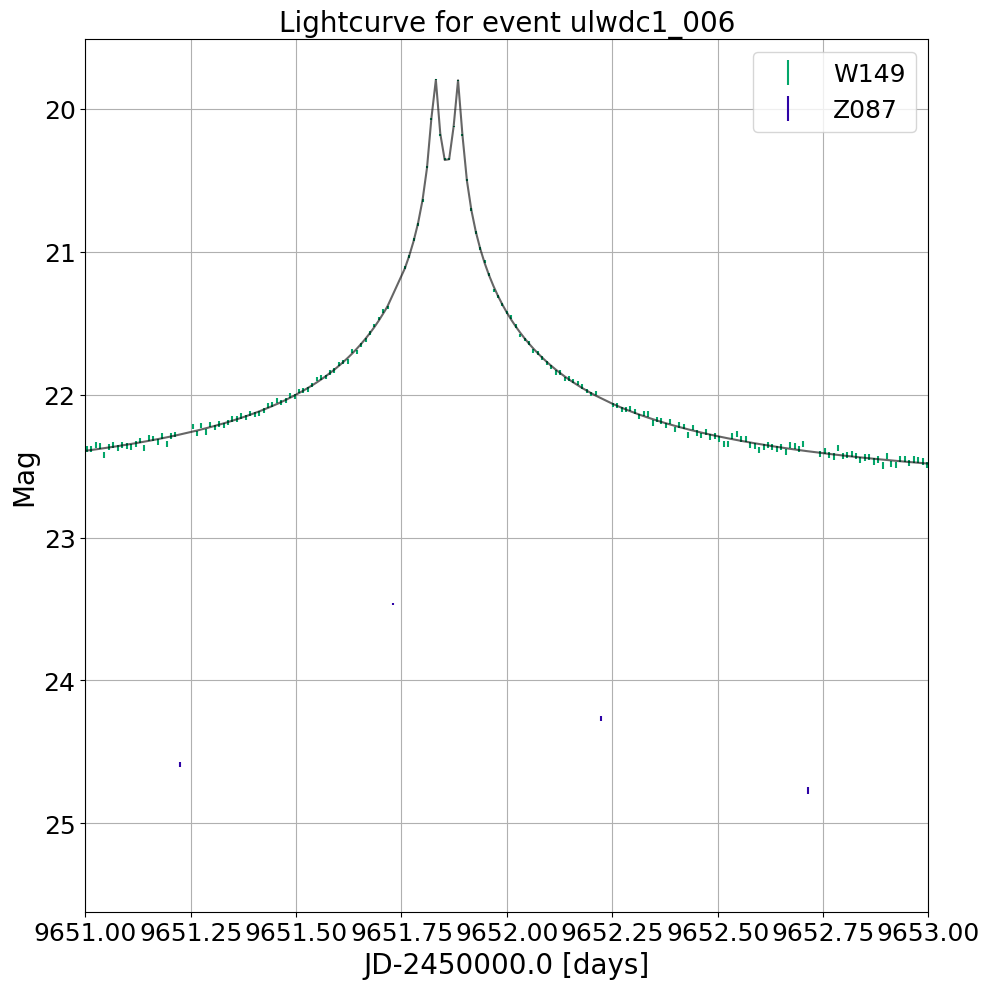

In [61]:
plot_file = path.join(DATA_DIR, eventID + '_model_lc.png')
plot_lc(wlc, zlc, 0.0, 0.0, plot_file, xmin=9651, xmax=9653, model_lc=model_telescope.lightcurve)

## Evaluating the impact of changing alpha
We now have a full baseline set of parameters for this event model, and the corresponding chi^2 value.  
We can now assess the change of chi^2 when alpha is changed by generating a series of models where the alpha is varied, while all other parameters are kept the same.  

In [67]:
def calc_chisq(event_model, pyLIMA_parameters):
    
    chichi = 0
    for telescope in event_model.event.telescopes:
        model = event_model.compute_the_microlensing_model(telescope, pyLIMA_parameters)[
            'photometry']
        flux = telescope.lightcurve['flux'].value
        errflux = telescope.lightcurve['err_flux'].value
        residus = (flux - model) / errflux
        chichi += (residus ** 2).sum()
        
    return chichi

In [112]:
alpha = np.arange(0.0, 360.0, 1.0) # Range of alpha in degrees
chichi = []
for a in alpha:
    pyLIMA_parameters = copy.deepcopy(baseline_pyLIMA_parameters) 
    pyLIMA_parameters['alpha'] = (a * np.pi) / 180.0
    chichi.append(calc_chisq(event_model, pyLIMA_parameters))
chichi = np.array(chichi)

Text(0, 0.5, '$\\chi^{2}$')

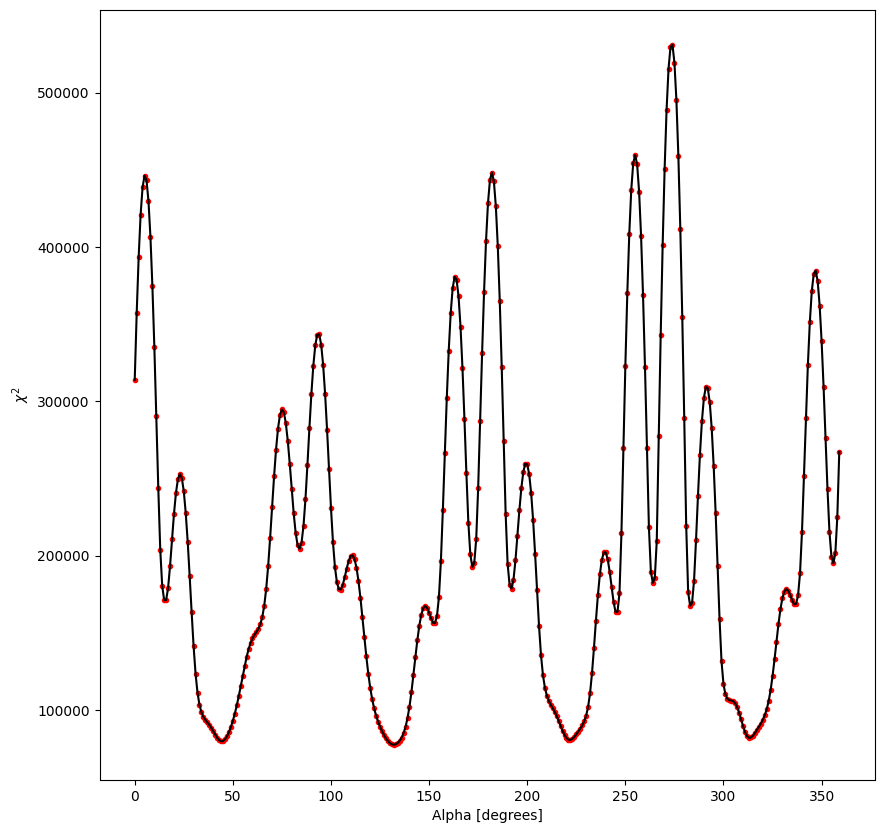

In [79]:
fig, axs = plt.subplots(1, 1, figsize=(10,10))
axs.plot(alpha, chichi, 'r.')
axs.plot(alpha, chichi, 'k-')
axs.set_xlabel('Alpha [degrees]')
axs.set_ylabel('$\chi^{2}$')

Interesting, and obviously cyclical, result with multiple nadirs of similar chi^2 spaced by ~90deg. This is a known degeneracy when the source intersects a symmetrical caustic, such as a central 'diamond' caustic.  The source's relative direction of travel can be from different directions and produce the same lightcurve.  

What's interesting here is the range of values of alpha around each minima that will produce lightcurves with quite similar chi^2 values when fitted to the data.  Combined with degeneracies in the direction of relative travel of the source and caustic structures that have symmetries, this can produce a wide range of potential 'good fits' to the data.  

Let's locate the alpha values for each minimum in chi^2. 

In [128]:
alpha_minima = []
chichi_minima = []

# Boundaries around the chi^2 minima
alpha_ranges = [(42.0, 46.0), (130.0, 134.0), (220.0, 224.0), (310.0, 315.0)]

for amin, amax in alpha_ranges:
    mask = (alpha >= amin) & (alpha <= amax)
    idx = np.argsort(chichi[mask])
    alpha_minima.append(alpha[mask][idx][0])
    chichi_minima.append(chichi[mask][idx][0])

for i in range(0, len(alpha_minima), 1): 
    print('Alpha = ', alpha_minima[i], 'deg, Chi^2 = ', chichi_minima[i])

Alpha =  44.0 deg, Chi^2 =  79680.94156397709
Alpha =  132.0 deg, Chi^2 =  77464.31034244323
Alpha =  222.0 deg, Chi^2 =  80603.03385442168
Alpha =  313.0 deg, Chi^2 =  81901.77414315724


Now let's plot the cautic plane and source trajectory for these models. 

Lens plane plot for alpha=44.0 deg
Lens plane plot for alpha=132.0 deg
Lens plane plot for alpha=222.0 deg
Lens plane plot for alpha=313.0 deg


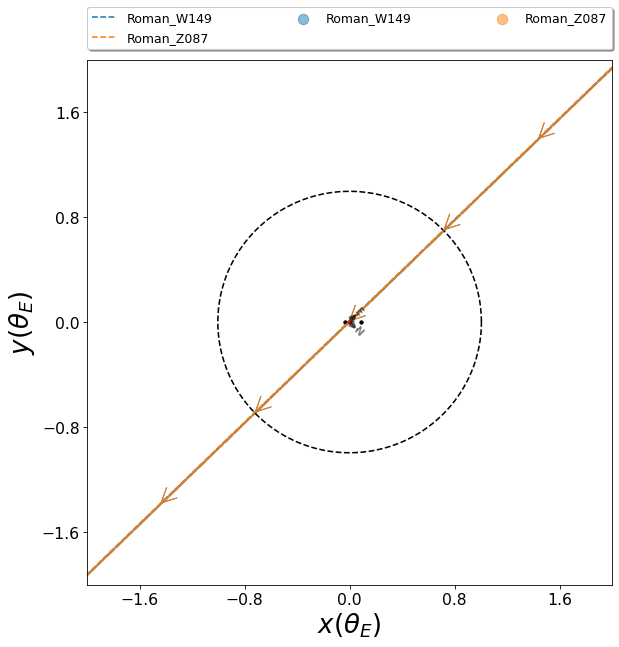

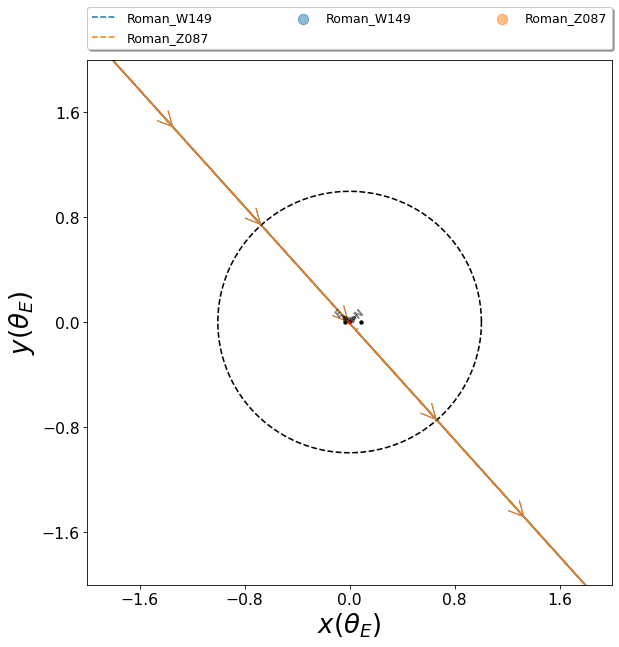

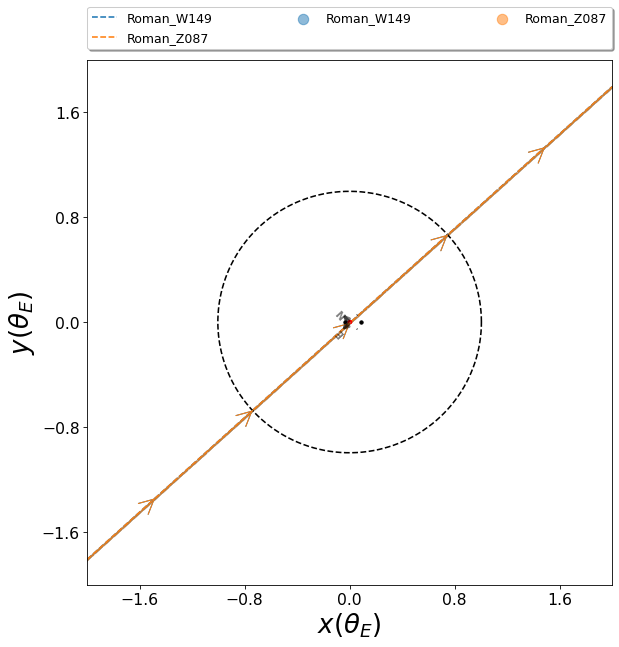

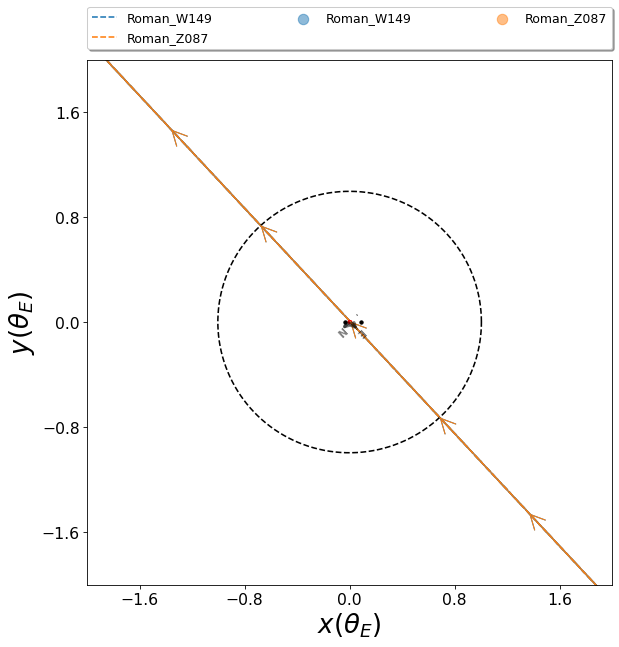

In [129]:
for a in alpha_minima:
    fit_results = copy.deepcopy(baseline_fit_results['best_model']) 
    fit_results[6] = (a * np.pi) / 180.0
    print('Lens plane plot for alpha='+str(a)+' deg')
    pyLIMA_plots.plot_geometry(event_model, fit_results)

So in the case of this lensing system, the source is crossing a central diamond caustic, which is symmetrical

Let's compare the model lightcurves from the best fitting models. 

In [130]:
def plot_alpha_range(alpha_min, alpha_max, alpha_incr, wlc, event_model, baseline_pyLIMA_parameters, xmin, xmax):
    PLOT_COLORS = {
        'W149': '#03A66A',
        'Z087': '#2E03A6'
        }
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
        
    dt = 2450000.0
    
    alpha = np.arange(alpha_min, alpha_max, alpha_incr) # Range of alpha in degrees
    chichi = []
    for a in alpha:
        pyLIMA_parameters = copy.deepcopy(baseline_pyLIMA_parameters) 
        pyLIMA_parameters['alpha'] = (a * np.pi) / 180.0
    
        # Plot datapoints
        axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], marker='d', ms=4, ls='none', c=PLOT_COLORS['W149'])
    
        # Generate and plot model lightcurve for this alpha
        model_telescope = generate_model_lightcurve(event_model, pyLIMA_parameters)
    
        axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='black', ls='-', alpha=0.6, label='$\alpha$=a deg')
    
    axs.invert_yaxis()
        
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.set_title('Lightcurve for event ' + eventID, fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    #axs.legend(fontsize=18)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    axs.set_xlim(xmin, xmax)

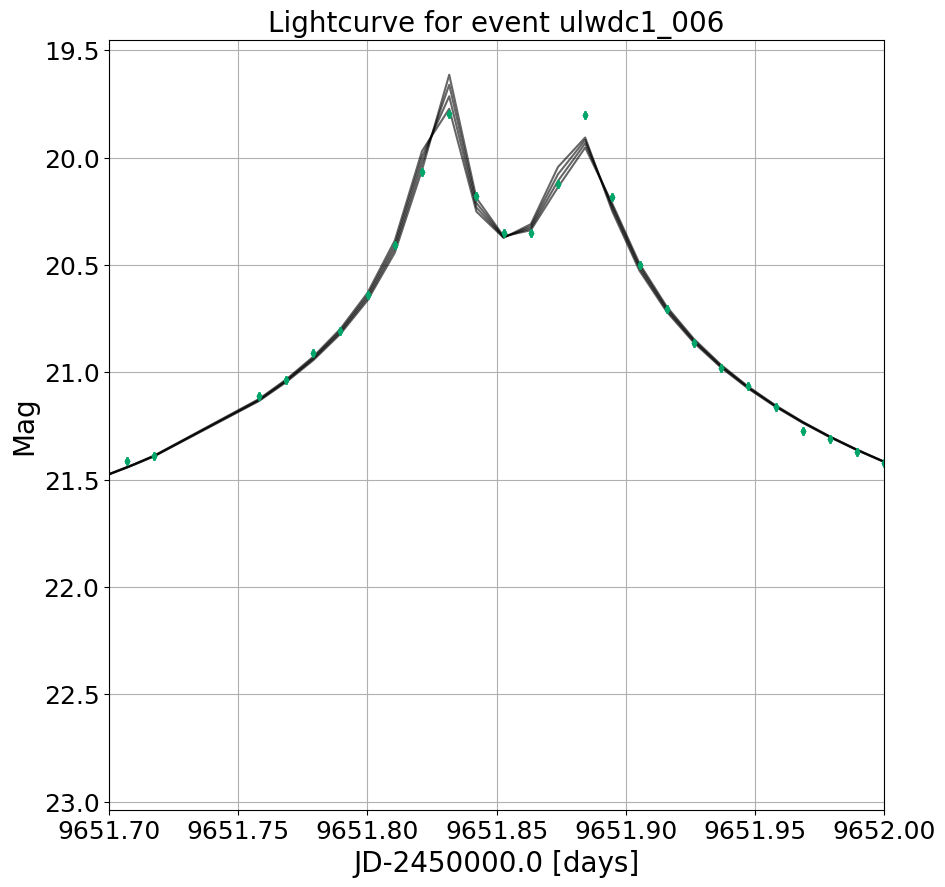

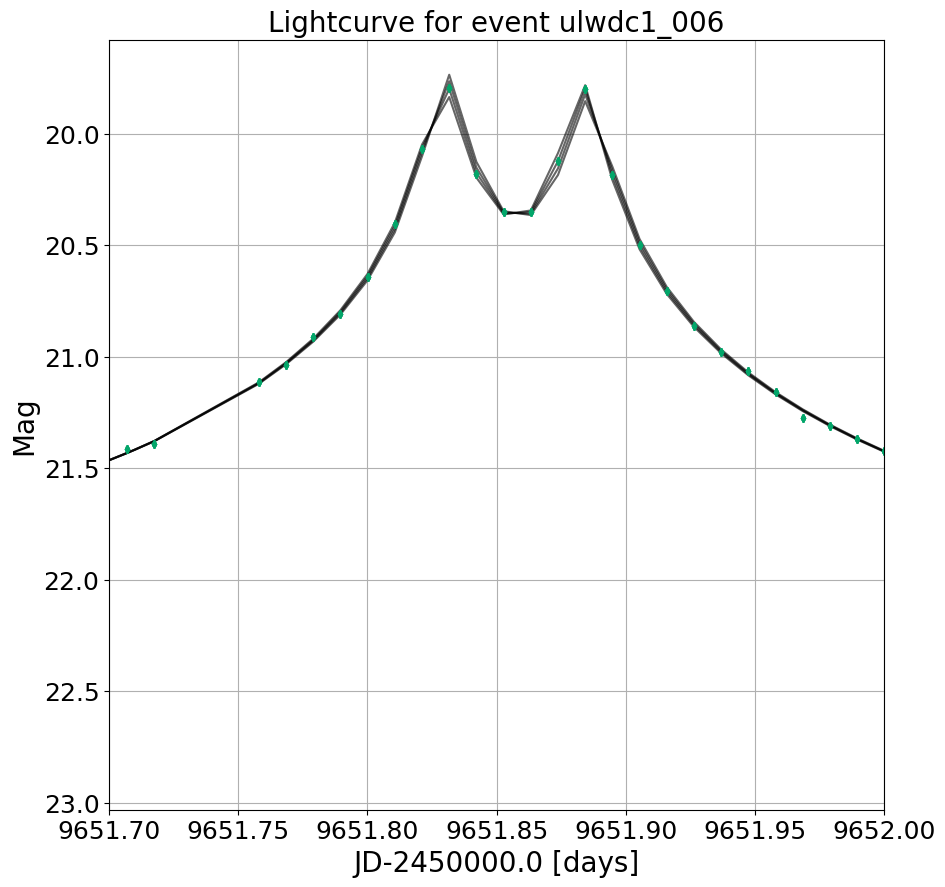

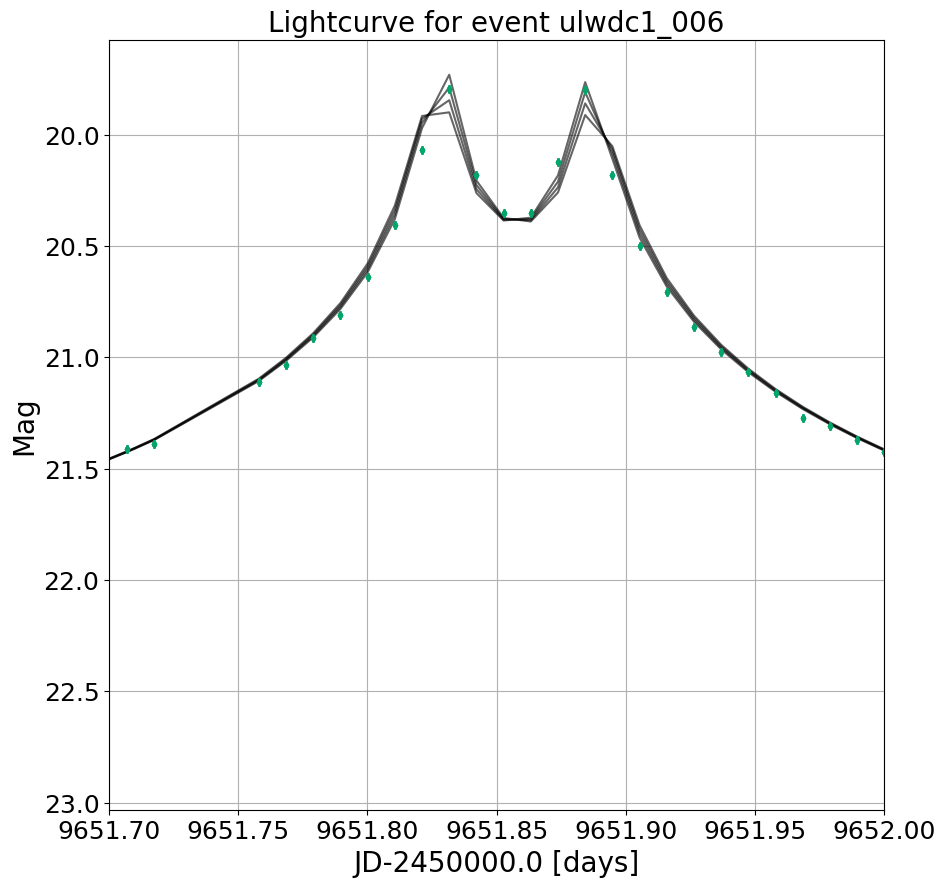

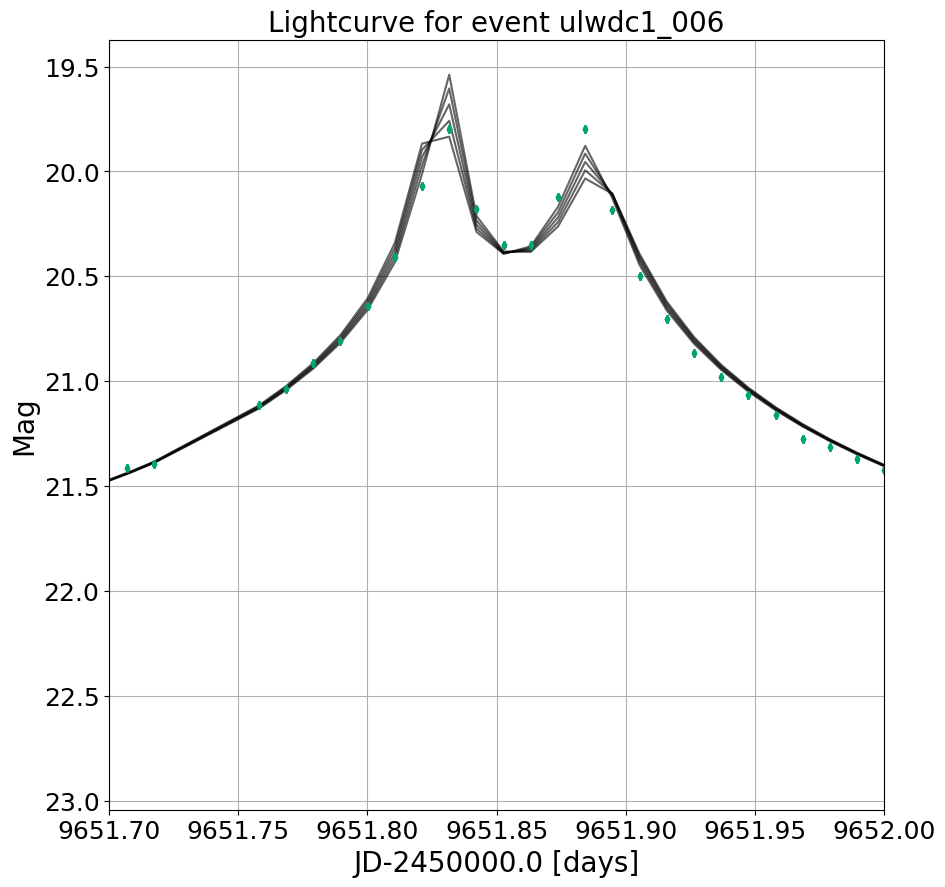

In [131]:
for amin, amax in alpha_ranges:
    plot_alpha_range(amin, amax, 1.0, wlc, event_model, baseline_pyLIMA_parameters, 9651.7, 9652.0)

As expected, the model lightcurves for alpha values around the chi^2 minima do have very similar shapes.  While they are not identical they are not well distinguished by data at the cadence of Roman lightcurves; as there is only a smaller number of outlier points, there is minimal impact on the overall chi^2. 

The chi^2 is still widely used in microlensing to identify the best model, often in combination with parameter-space exploring algorithms like MCMC.  This would explain the wide range of alpha values submitted by teams in the data challenge, for models whose parameters were otherwise correct.  

This would argue towards exploring alternative statistics for identifying the best model.  